In [12]:
## Assuming Distribution is Gaussian for each class
## And finding MLE best fit Gaussian for each class (uk(mean) accross features for class kth class , covariance matrix for the kth class data )
## for new Sample x -> probability of x belong to that class

In [1]:
import pandas  as pd
import numpy as np

In [48]:

housing_data = pd.read_csv('../datasets/IRIS.csv')

In [49]:
housing_data

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


In [50]:
## spitting into 80-20 
from sklearn.model_selection import train_test_split
train_df, test_df =train_test_split(housing_data, test_size=0.2,stratify=housing_data['species'],random_state= 42)

In [51]:
train_df['species'].unique().tolist()

['Iris-setosa', 'Iris-virginica', 'Iris-versicolor']

In [52]:
label = 'Iris-versicolor'

In [10]:
df_iris_setosa = train_df[train_df['species'] ==label].reset_index(drop =True)

## droping species column
u_iris_setosa = df_iris_setosa.drop(columns = ['species'])

## numpy  
u_iris_setosa = u_iris_setosa.values

## taking mean
u_iris_setosa  = np.mean(u_iris_setosa, axis = 0)
u_iris_setosa = u_iris_setosa.reshape(1,-1)


## Covariance_matrix  just by using numpy
##(x-u)@(x-u).T
X_iris_setos = df_iris_setosa.drop(columns = ['species']).values
cov_iris_setosa = (X_iris_setos - u_iris_setosa).T@(X_iris_setos - u_iris_setosa)/(len(df_iris_setosa))
pie_iris_setosa= train_df['species'].value_counts()['Iris-setosa']/train_df['species'].value_counts().sum()


### Bayes theorem
![Screenshot from 2026-04-02 12-54-36.png](<attachment:Screenshot from 2026-04-02 12-54-36.png>)

### Multivariate Normal Distribution
![Screenshot from 2026-04-02 12-57-57.png](<attachment:Screenshot from 2026-04-02 12-57-57.png>)

### Prediction time
![Screenshot from 2026-04-02 13-01-24.png](<attachment:Screenshot from 2026-04-02 13-01-24.png>)

### taking log to avoid underflow (very small values not go to Zero)
![Screenshot from 2026-04-02 13-03-13.png](<attachment:Screenshot from 2026-04-02 13-03-13.png>)

### whole gaussian distribution to implement
![Screenshot from 2026-04-04 18-34-03.png](<attachment:Screenshot from 2026-04-04 18-34-03.png>)
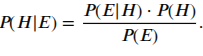
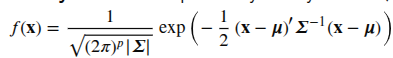
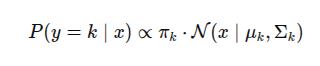
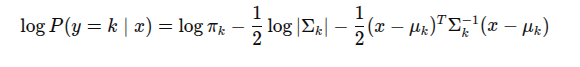
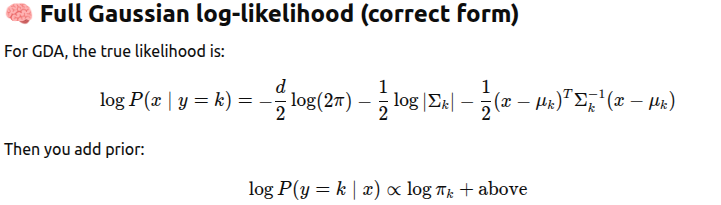

In [11]:
## taking sample from text df 
sample_point = test_df.sample(1, random_state=42)

In [12]:
y_test = sample_point['species']

In [13]:
y_test

18    Iris-setosa
Name: species, dtype: object

In [14]:
x_test = sample_point.drop(columns =['species']).values

In [15]:
x_test.shape

(1, 4)

In [16]:
pie = np.round(pie_iris_setosa,2).item()

In [17]:
## prior probability of  class iris-setosa
first_term = np.log(pie)

In [18]:
## second term is 0.5*determinant(covariance matrix)
second_term = 0.5*np.log(np.linalg.det(cov_iris_setosa))

In [19]:
## x-u, cov inverse, (x-u).T
x_minus_u = x_test-u_iris_setosa
inverse_of_cov = np.linalg.inv(cov_iris_setosa)
x_minus_u_transpose = x_minus_u.T
third_term = 0.5*(x_minus_u@inverse_of_cov@x_minus_u_transpose)

In [20]:
value_versicolor = first_term - second_term -third_term

In [21]:
first_term,second_term,third_term

(np.float64(-1.1086626245216111),
 np.float64(-5.438554519819839),
 array([[57.81383268]]))

In [22]:
value_versicolor

array([[-53.48394079]])

In [23]:
# value_setosa, value_verginica, value_versicolor

In [24]:
np.e**value_versicolor[0]

array([5.91860893e-24])

In [25]:
## third term



In [26]:
## at the time of prediction  from bayes rule
## 
## p([y=k]/x) = p(x/[y=k])*p(y=k)/p(x)
## Here p(x) will be common for class so for comparision we don't want this shit


In [27]:
train_df['species'].value_counts()['Iris-setosa']/train_df['species'].value_counts().sum()

np.float64(0.3333333333333333)

In [28]:
u_iris_setosa

array([[5.93  , 2.75  , 4.2525, 1.32  ]])

In [29]:
cov_iris_setosa

array([[0.2216    , 0.06375   , 0.146175  , 0.0399    ],
       [0.06375   , 0.093     , 0.061125  , 0.03275   ],
       [0.146175  , 0.061125  , 0.19149375, 0.05895   ],
       [0.0399    , 0.03275   , 0.05895   , 0.0341    ]])

In [30]:
u_iris_setosa


array([[5.93  , 2.75  , 4.2525, 1.32  ]])

In [31]:
u_iris_setosa.shape

(1, 4)

In [32]:
u_iris_setosa = np.mean(u_iris_setosa, axis = 0)

u_iris_setosa

array([5.93  , 2.75  , 4.2525, 1.32  ])

In [33]:
train_df['species'].unique()

array(['Iris-setosa', 'Iris-virginica', 'Iris-versicolor'], dtype=object)

## FINAL GDA CODE

In [4]:
import os
os.getcwd()

'/home/mfaizan/personal/FROM_SCRATCH_ML/GDA_and_LDA_from_Scratch'

In [7]:
##################### Reading IRIS DATA ####################################################

iris_data = pd.read_csv('/home/mfaizan/personal/FROM_SCRATCH_ML/datasets/IRIS.csv')

############################################################################################


## spitting into 80-20 
from sklearn.model_selection import train_test_split
train_df, test_df =train_test_split(iris_data, test_size=0.2,stratify=iris_data['species'],random_state= 42)

## creating function to generate model parameteters by class
def generate_parameters_of_distribution(df:pd.DataFrame, label_name :str):
    pie= df['species'].value_counts()[label_name]/df['species'].value_counts().sum()
    df = df[df['species'] ==label_name].reset_index(drop =True)

    ## droping species column
    u = df.drop(columns = ['species'])

    ## numpy  
    u = u.values

    ## taking mean
    u  = np.mean(u, axis = 0)
    u = u.reshape(1,-1)


    ## Covariance_matrix  just by using numpy
    ##(x-u)@(x-u).T
    x = df.drop(columns = ['species']).values
    cov = (x - u).T@(x - u)/(len(df))

    return u, cov, pie # prior probability


parameters = {}
labels = train_df['species'].unique().tolist()

################################## initializing parameters ######################################
for label in labels:
    parameters[label] = []

for label in labels:
    u, cov, pie= generate_parameters_of_distribution(train_df, label)
    parameters[label].append(u); parameters[label].append(cov); parameters[label].append(pie); 


def get_probability(data_point,paramerters ):
    x = data_point.drop(columns= ['species']).values
    u, cov, prior = paramerters[0], paramerters[1], paramerters[2]
    d = x.shape[1]

    zero_term = (d)*(np.log(2*np.pi))/2
    first_term = np.log(prior)
    second_term = 0.5*np.log(np.linalg.det(cov))

    ## x-u, cov inverse, (x-u).T
    x_minus_u = x-u
    inverse_of_cov = np.linalg.inv(cov)
    x_minus_u_transpose = x_minus_u.T
    third_term = 0.5*(x_minus_u@inverse_of_cov@x_minus_u_transpose)

    return (first_term - zero_term - second_term - third_term).item()


def predict_sample(parameters, data_point):
    labels_with_prediction = {}
    for label, value in parameters.items():
        prob = get_probability(data_point, value)
        labels_with_prediction[label] = prob
    
    return labels_with_prediction

count  = 0

for i in range(1,len(test_df)+1):
    data_point = test_df[i-1:i]
    true_label = data_point.iloc[0]['species']
    result =  predict_sample(parameters,data_point)
    label = max(result, key=result.get)

    print(f"prediction: {label}")
    print(f"true label: {true_label}")

    count +=(int)(label==true_label)
    print("***********************************")

    

prediction: Iris-setosa
true label: Iris-setosa
***********************************
prediction: Iris-virginica
true label: Iris-virginica
***********************************
prediction: Iris-versicolor
true label: Iris-versicolor
***********************************
prediction: Iris-versicolor
true label: Iris-versicolor
***********************************
prediction: Iris-setosa
true label: Iris-setosa
***********************************
prediction: Iris-versicolor
true label: Iris-versicolor
***********************************
prediction: Iris-setosa
true label: Iris-setosa
***********************************
prediction: Iris-setosa
true label: Iris-setosa
***********************************
prediction: Iris-virginica
true label: Iris-virginica
***********************************
prediction: Iris-versicolor
true label: Iris-versicolor
***********************************
prediction: Iris-virginica
true label: Iris-virginica
***********************************
prediction: Iris-virginica

In [37]:
count/len(test_df)

0.9

📌 How Covariance Affects GDA (Simple Explanation)
🎯 Big Idea

Covariance controls how spread out a class is.

Small covariance → data is tight and concentrated
Large covariance → data is wide and spread out
⚖️ Two Opposite Effects
✅ Effect 1: Distance becomes less important
When covariance is large, the model is more “forgiving”
Even if a point is far from the mean, it doesn’t penalize much
👉 This helps probability increase
❌ Effect 2: Confidence becomes lower
When covariance is large, data is spread everywhere
So the model is less confident about any specific point
👉 This reduces probability
🔥 Key Insight

Large covariance both helps and hurts at the same time

Helps → reduces distance penalty
Hurts → spreads probability thin
🧠 Easy Intuition

Think of it like this:

Small covariance → 🎯 Sniper
Very accurate
Strong near the center
Fails quickly far away
Large covariance → 💥 Shotgun
Covers large area
Works better far away
Less precise near center
📊 Simple Example

We have 2 classes:

Class A → tight (small covariance)
Class B → wide (large covariance)
Case 1: Point is near center
Class A → very confident
Class B → not very confident

👉 Prediction = Class A

Case 2: Point is far away
Class A → says “too far!”
Class B → says “still possible”

👉 Prediction = Class B

💥 Final Takeaway
Near mean → small covariance wins
Far from mean → large covariance wins
🧠 One-line Memory Trick

Covariance controls how far a class can reach

## LDA -> Linear Discriminant Analysis


In [72]:
import numpy as np
import pandas as pd

def get_covariance(df: pd.DataFrame):
    unique_labels = df['species'].unique()
    
    list_of_x_minus_u = []
    total_samples = 0
    
    for label in unique_labels:
        df_label = df[df['species'] == label]
        
        x = df_label.drop(columns=['species']).values
        total_samples += len(x)
        
        x_mean = np.mean(x, axis=0, keepdims=True)
        list_of_x_minus_u.append(x - x_mean)
    
    x_minus_u = np.concatenate(list_of_x_minus_u, axis=0)
    
    K = len(unique_labels)
    cov = (x_minus_u.T @ x_minus_u) / (total_samples - K) ## Normalized by n-k for unbiased estimation of covariance matrix
    
    return cov


##  for LDA we will assume that covariance matrix is same for all class and we will take common covariance matrix by taking mean of covariance matrix of each class
## samples that are belongs to which class u of that class going to subtract from sample point and then we will take common covariance matrix inverse and then we will do the same thing as we did in GDA
def get_parameters_of_distribution(df:pd.DataFrame, target_column: str, label_name :str):
    pie= df[target_column].value_counts()[label_name]/df[target_column].value_counts().sum()
    df = df[df[target_column] ==label_name].reset_index(drop =True)

    ## droping species column
    u = df.drop(columns = [target_column])

    ## numpy  
    u = u.values

    ## taking mean
    u  = np.mean(u, axis = 0)
    u = u.reshape(1,-1)

    return u, pie # prior probability


def fit_model(train_df: pd.DataFrame):
    parameters = {}
    labels = train_df['species'].unique().tolist()
    
    for label in labels:
        parameters[label] = []
    
    for label in labels:
        u, pie= get_parameters_of_distribution(train_df, 'species', label)
        parameters[label].append(u); parameters[label].append(pie); 

    common_cov = get_covariance(train_df)

    for label in labels:
        parameters[label].insert(1, common_cov) ## inserting common covariance matrix at index 1

    return parameters


parameters = fit_model(train_df)


### getting prediction for test data

cov = get_covariance(train_df)
all_classes = parameters.keys()

results = {'prediction': [], 'true_label': []}

for i in range(len(test_df)):
    data_point = test_df.iloc[i:i+1]
    result = None
    highest_probability =  -np.inf
    for label in all_classes:
        u = parameters[label][0]

        prior = parameters[label][2]

        x = data_point.drop(columns = ['species']).values

        d = x.shape[1]
        zero_term = (d)*(np.log(2*np.pi))/2
        first_term = np.log(prior)
        second_term = 0.5*np.log(np.linalg.det(cov))

        x_minus_u = x-u
        x_minus_u_transpose = x_minus_u.T
        inverse_of_cov = np.linalg.inv(cov)
        third_term = 0.5*(x_minus_u@inverse_of_cov@x_minus_u_transpose)

        probability = first_term - zero_term - second_term - third_term

        if probability > highest_probability:
            highest_probability = probability
            result  = label

    results['prediction'].append(result)
    results['true_label'].append(data_point['species'].values[0])



results_df = pd.DataFrame(results)
(results_df['prediction']==results_df['true_label']).sum()/len(results_df)

np.float64(1.0)

In [73]:
results_df = pd.DataFrame(results)

In [ ]:
import numpy as np
import pandas as pd

def get_covariance(df: pd.DataFrame):
    unique_labels = df['species'].unique()
    
    list_of_x_minus_u = []
    total_samples = 0
    
    for label in unique_labels:
        df_label = df[df['species'] == label]
        
        x = df_label.drop(columns=['species']).values
        total_samples += len(x)
        
        x_mean = np.mean(x, axis=0, keepdims=True)
        list_of_x_minus_u.append(x - x_mean)
    
    x_minus_u = np.concatenate(list_of_x_minus_u, axis=0)
    
    K = len(unique_labels)
    cov = (x_minus_u.T @ x_minus_u) / (total_samples - K) ## Normalized by n-k for unbiased estimation of covariance matrix
    
    return cov



    

In [64]:
##  for LDA we will assume that covariance matrix is same for all class and we will take common covariance matrix by taking mean of covariance matrix of each class
## samples that are belongs to which class u of that class going to subtract from sample point and then we will take common covariance matrix inverse and then we will do the same thing as we did in GDA
def get_parameters_of_distribution(df:pd.DataFrame, target_column: str, label_name :str):
    pie= df[target_column].value_counts()[label_name]/df[target_column].value_counts().sum()
    df = df[df[target_column] ==label_name].reset_index(drop =True)

    ## droping species column
    u = df.drop(columns = [target_column])

    ## numpy  
    u = u.values

    ## taking mean
    u  = np.mean(u, axis = 0)
    u = u.reshape(1,-1)

    return u, pie # prior probability


def fit_model(train_df: pd.DataFrame):
    parameters = {}
    labels = train_df['species'].unique().tolist()
    
    for label in labels:
        parameters[label] = []
    
    for label in labels:
        u, pie= get_parameters_of_distribution(train_df, 'species', label)
        parameters[label].append(u); parameters[label].append(pie); 

    common_cov = get_covariance(train_df)

    for label in labels:
        parameters[label].insert(1, common_cov) ## inserting common covariance matrix at index 1

    return parameters

In [65]:
parameters = fit_model(train_df)

In [66]:
parameters

{'Iris-setosa': [array([[4.985 , 3.4025, 1.48  , 0.2525]]),
  array([[0.2638547 , 0.09161966, 0.17019658, 0.03411538],
         [0.09161966, 0.12712607, 0.05744444, 0.03339103],
         [0.17019658, 0.05744444, 0.18468162, 0.04164103],
         [0.03411538, 0.03339103, 0.04164103, 0.04033974]]),
  np.float64(0.3333333333333333)],
 'Iris-virginica': [array([[6.61, 2.98, 5.58, 2.04]]),
  array([[0.2638547 , 0.09161966, 0.17019658, 0.03411538],
         [0.09161966, 0.12712607, 0.05744444, 0.03339103],
         [0.17019658, 0.05744444, 0.18468162, 0.04164103],
         [0.03411538, 0.03339103, 0.04164103, 0.04033974]]),
  np.float64(0.3333333333333333)],
 'Iris-versicolor': [array([[5.93  , 2.75  , 4.2525, 1.32  ]]),
  array([[0.2638547 , 0.09161966, 0.17019658, 0.03411538],
         [0.09161966, 0.12712607, 0.05744444, 0.03339103],
         [0.17019658, 0.05744444, 0.18468162, 0.04164103],
         [0.03411538, 0.03339103, 0.04164103, 0.04033974]]),
  np.float64(0.3333333333333333)]}

In [67]:

### getting prediction for test data

cov = get_covariance(train_df)
all_classes = parameters.keys()

results = {'prediction': [], 'true_label': []}

for i in range(len(test_df)):
    data_point = test_df.iloc[i:i+1]
    result = None
    highest_probability =  -np.inf
    for label in all_classes:
        u = parameters[label][0]

        prior = parameters[label][2]

        x = data_point.drop(columns = ['species']).values

        d = x.shape[1]
        zero_term = (d)*(np.log(2*np.pi))/2
        first_term = np.log(prior)
        second_term = 0.5*np.log(np.linalg.det(cov))

        x_minus_u = x-u
        x_minus_u_transpose = x_minus_u.T
        inverse_of_cov = np.linalg.inv(cov)
        third_term = 0.5*(x_minus_u@inverse_of_cov@x_minus_u_transpose)

        probability = first_term - zero_term - second_term - third_term

        if probability > highest_probability:
            highest_probability = probability
            result  = label

    results['prediction'].append(result)
    results['true_label'].append(data_point['species'].values[0])

In [71]:
results_df = pd.DataFrame(results)
(results_df['prediction']==results_df['true_label']).sum()/len(results_df)

np.float64(1.0)